# Assignment 1

## TDA for handling Image data

The Persistent Homology Pipeline
1. Construct a nested sequence (filtration) of simplicial complexes
2. Track the birth and death of topological features: connected components, loops, voids
3. This should result in a multi-scale representation of shapes
4. Significant topological features are highlighted and noise is filtered out
5. ML integration

In [1]:
!pip3 install giotto-tda gudhi

In [3]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
pip install scipy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
pip install gtda

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement gtda (from versions: none)
ERROR: No matching distribution found for gtda

[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
pip install numpy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from sklearn.datasets import fetch_openml
import numpy as np
from gtda.plotting import plot_heatmap
from sklearn.model_selection import train_test_split
from gtda.images import Binarizer
from gtda.images import RadialFiltration, HeightFiltration, DilationFiltration, DensityFiltration, ErosionFiltration
from gtda.homology import CubicalPersistence
from gtda.diagrams import Scaler, HeatKernel

In [3]:
X, y = fetch_openml("mnist_784", version=1, return_X_y=True, parser='auto')

In [4]:
print(f"X shape: {X.shape}, y shape: {y.shape}")

X shape: (70000, 784), y shape: (70000,)


In [5]:
pip install --upgrade nbformat

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
X = np.array(X)
y = np.array(y)

im8_idx = np.flatnonzero(y == "8")[0]
img8 = X[im8_idx].reshape(28, 28)
plot_heatmap(img8)

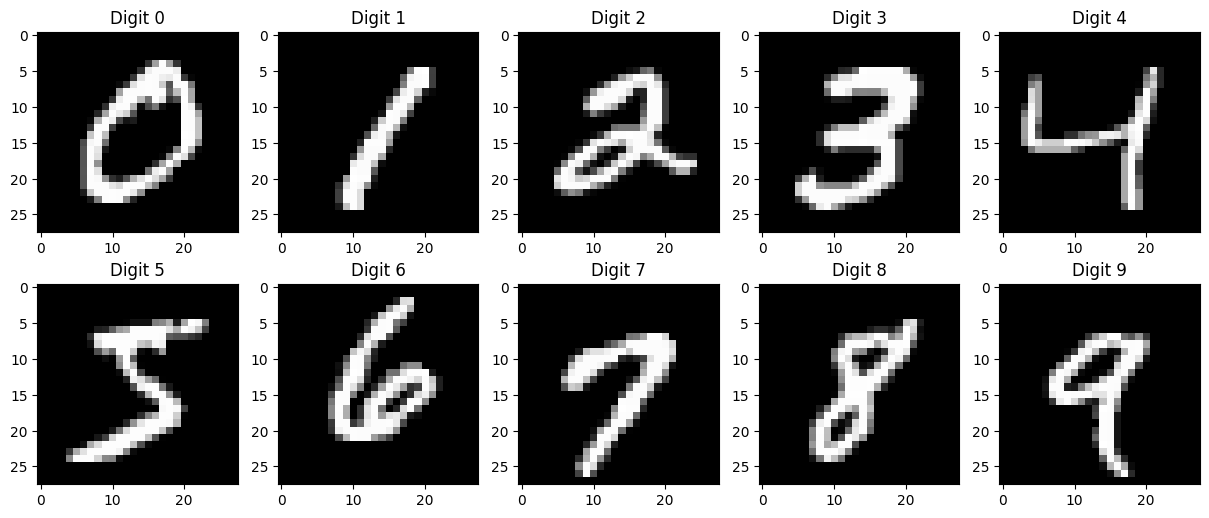

In [7]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i in range(10):
    im_idx = np.flatnonzero(y == str(i))[0]
    img = X[im_idx].reshape(28, 28)
    ax = plot_heatmap(img)
    plt.axes(axes[i // 5, i % 5])
    plt.imshow(img, cmap='gray')
    plt.title(f"Digit {i}")


In [8]:
train_size, test_size = 60, 10

X = X.reshape((-1, 28, 28))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=train_size, test_size=test_size, stratify=y, random_state=666
)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train shape: (60, 28, 28), y_train shape: (60,)
X_test shape: (10, 28, 28), y_test shape: (10,)


### Binarize the greyscale Image

In [9]:
# Pick out index of first 8 image
im8_idx = np.flatnonzero(y_train == "8")[0]
# Reshape to (n_samples, n_pixels_x, n_pixels_y) format
im8 = X_train[im8_idx][None, :, :]

binarizer = Binarizer(threshold=0.4)
im8_binarized = binarizer.fit_transform(im8)

binarizer.plot(im8_binarized)

### Visualizing Radial Filtration

In [10]:
radial_filtration = RadialFiltration(center=np.array([14, 5]))
im8_filtration = radial_filtration.fit_transform(im8_binarized)

radial_filtration.plot(im8_filtration, colorscale="jet")

In [11]:
height_filtration = HeightFiltration(direction=np.array([0, -1]))
im8_filtration = height_filtration.fit_transform(im8_binarized)
height_filtration.plot(im8_filtration, colorscale="jet")

### Persistence Diagram

In [12]:
cubical_persistence = CubicalPersistence(n_jobs=-1)
im8_cubical = cubical_persistence.fit_transform(im8_filtration)

cubical_persistence.plot(im8_cubical)

In [18]:
im8_cubical

array([[[ 0.,  0.,  0.],
        [11., 28.,  1.],
        [22., 28.,  1.]]])

In [35]:
type(cubical_persistence)

gtda.homology.cubical.CubicalPersistence

In [61]:
scaler = Scaler()
im8_scaled = scaler.fit_transform(im8_cubical)

scaler.plot(im8_scaled)

## Training an Image Classifier on MNIST data

In [13]:
from sklearn.pipeline import make_pipeline, make_union
from gtda.diagrams import PersistenceEntropy, Amplitude
from gtda.images import HeightFiltration
from sklearn.ensemble import RandomForestClassifier

In [14]:
direction_list = [[1, 0], [1, 1], [0, 1], [-1, 1], [-1, 0], [-1, -1], [0, -1], [1, -1]]
center_list = [
    [13, 4],
    [4, 13],
    [13, 13],
    [20, 13],
    [13, 20],
    [5, 5],
    [5, 20],
    [20, 5],
    [20, 20],
]

In [15]:
from sklearn.base import BaseEstimator, TransformerMixin
import numpy as np

class Normalize255(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.astype(np.float32)
        return (255.0 - X)/255.0

In [16]:
# Creating a list of all filtration transformer, we will be applying
filtration_list = ( [HeightFiltration(direction=np.array(direction), n_jobs=-1) for direction in direction_list]
    + [RadialFiltration(center=np.array(center), n_jobs=-1) for center in center_list] )

diagram_steps = [
    [   Binarizer(threshold=0.4, n_jobs=-1),
        filtration,
        CubicalPersistence(n_jobs=-1),
        Scaler(n_jobs=-1),
    ]
    for filtration in filtration_list
]

# Add one extra pipeline WITHOUT binarizer & filtration
step = [
    Normalize255(),
    CubicalPersistence(n_jobs=-1),
    Scaler(n_jobs=-1),
]

diagram_steps += [step] * 3

In [ ]:
# Listing all metrics we want to use to extract diagram amplitudes
metric_list = [
    {"metric": "bottleneck", "metric_params": {}},
    {"metric": "wasserstein", "metric_params": {"p": 1}},
    {"metric": "wasserstein", "metric_params": {"p": 2}},
    #{"metric": "landscape", "metric_params": {"p": 1, "n_layers": 1, "n_bins": 100}},
    #{"metric": "landscape", "metric_params": {"p": 1, "n_layers": 2, "n_bins": 100}},
    {"metric": "landscape", "metric_params": {"p": 2, "n_layers": 1, "n_bins": 100}},
    {"metric": "landscape", "metric_params": {"p": 2, "n_layers": 2, "n_bins": 100}},
    {"metric": "betti", "metric_params": {"p": 1, "n_bins": 100}},
    {"metric": "betti", "metric_params": {"p": 2, "n_bins": 100}},
    # {"metric": "heat", "metric_params": {"p": 1, "sigma": 1.6, "n_bins": 100}},
    # {"metric": "heat", "metric_params": {"p": 1, "sigma": 3.2, "n_bins": 100}},
    # {"metric": "heat", "metric_params": {"p": 2, "sigma": 1.6, "n_bins": 100}},
    # {"metric": "heat", "metric_params": {"p": 2, "sigma": 3.2, "n_bins": 100}},
]

In [24]:
feature_union = make_union(
    *[PersistenceEntropy(nan_fill_value=-1)]
    + [Amplitude(**metric, n_jobs=-1) for metric in metric_list]
)

tda_union = make_union(
    *[make_pipeline(*diagram_step, feature_union) for diagram_step in diagram_steps],
    n_jobs=-1
)

In [19]:
X, y = fetch_openml("mnist_784", version=1, return_X_y=True, parser='auto')
train_size, test_size = 800, 200

X = np.array(X)
y = np.array(y)

X = X.reshape((-1, 28, 28))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=train_size, test_size=test_size, stratify=y, random_state=666
)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train shape: (800, 28, 28), y_train shape: (800,)
X_test shape: (200, 28, 28), y_test shape: (200,)


In [25]:
X_train_tda = tda_union.fit_transform(X_train)
X_train_tda.shape

(800, 280)

In [26]:
rf = RandomForestClassifier()
rf.fit(X_train_tda, y_train)

X_test_tda = tda_union.transform(X_test)
rf.score(X_test_tda, y_test)


0.87

In [22]:
#X_train_tda.shape = (n_samples, n_features)
import pandas as pd

n_features = X_train_tda.shape[1]
feature_names = [f"f{i}" for i in range(n_features)]

# Convert to DataFrame for easier handling
X_df = pd.DataFrame(X_train_tda, columns=feature_names)

# 1. Train Random Forest
rf = RandomForestClassifier(
    n_estimators=1000,
    n_jobs=-1,
    random_state=42
)
rf.fit(X_df, y_train)

# 2. Get feature importances
feature_importances = pd.Series(rf.feature_importances_, index=feature_names)
feature_importances = feature_importances.sort_values(ascending=False)

# 3. Keep features with non-zero importance (you can apply a threshold)
top_features = feature_importances[feature_importances > 0].index
X_top = X_df[top_features]

# 4. Compute correlation matrix
corr_matrix = X_top.corr().abs()

# 5. Drop one feature from each pair with correlation >= 0.9
to_drop = set()
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        if corr_matrix.iloc[i, j] >= 0.9:
            # Drop the feature with lower importance
            if feature_importances[corr_matrix.columns[i]] > feature_importances[corr_matrix.columns[j]]:
                to_drop.add(corr_matrix.columns[j])
            else:
                to_drop.add(corr_matrix.columns[i])

X_selected_df = X_top.drop(columns=list(to_drop))
X_selected = X_selected_df.to_numpy()

print(f"Original features: {X_train_tda.shape[1]}")
print(f"After RF importance filter: {X_top.shape[1]}")
print(f"After correlation filter: {X_selected.shape[1]}")

Original features: 320
After RF importance filter: 320
After correlation filter: 38


## Training An Image Classifier on Fashion MNIST

In [171]:
pip install torch

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [172]:
pip install torchvision

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Question: Do the features extracted by CNN have any topological features? 

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline, make_union
from gtda.diagrams import PersistenceEntropy, Amplitude
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import fetch_openml
import numpy as np
from gtda.plotting import plot_heatmap
from sklearn.model_selection import train_test_split
from gtda.images import Binarizer
from gtda.images import RadialFiltration, HeightFiltration, DilationFiltration, DensityFiltration, ErosionFiltration
from gtda.homology import CubicalPersistence
from gtda.diagrams import Scaler, HeatKernel
from sklearn.base import BaseEstimator, TransformerMixin
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, adjusted_rand_score
from scipy.stats import mode

In [2]:
# ------------------------------
# 1. Load Fashion-MNIST
# ------------------------------
transform = transforms.Compose([
    transforms.ToTensor(),              # convert to tensor [0,1]
    transforms.Normalize((0.5,), (0.5,)) # normalize to [-1,1]
])

train_dataset = datasets.FashionMNIST(root='./data', train=True,
                                      download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root='./data', train=False,
                                     download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

# ------------------------------
# 2. Define CNN
# ------------------------------
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)  
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1) 
        self.pool = nn.MaxPool2d(2, 2)                           
        self.fc1 = nn.Linear(64*7*7, 128)  # FIXED
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   # -> [32,14,14]
        x = self.pool(F.relu(self.conv2(x)))   # -> [64,7,7]
        x = x.view(-1, 64*7*7)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = SimpleCNN()

# ------------------------------
# 3. Loss + Optimizer
# ------------------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ------------------------------
# 4. Training Loop
# ------------------------------
for epoch in range(3):  # train for 5 epochs
    model.train()
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
    
    # evaluate on test set
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    acc = 100 * correct / total
    print(f"Epoch {epoch+1}: Test Accuracy = {acc:.2f}%")

Epoch 1: Test Accuracy = 86.96%
Epoch 2: Test Accuracy = 90.03%
Epoch 3: Test Accuracy = 90.48%


In [3]:
# Dictionary to store outputs
feature_maps = {}

def get_activation(name):
    def hook(model, input, output):
        feature_maps[name] = output.detach()
    return hook

# Register hooks on conv + fc layers
model.conv1.register_forward_hook(get_activation('conv1'))
model.conv2.register_forward_hook(get_activation('conv2'))
model.fc1.register_forward_hook(get_activation('fc1'))
model.fc2.register_forward_hook(get_activation('fc2'))


In [4]:
# Take one test image
image, label = test_dataset[0]
image = image.unsqueeze(0)  # add batch dimension

# Run model forward
model.eval()
with torch.no_grad():
    output = model(image)

print("Predicted class:", output.argmax(dim=1).item())

for layer_name, activation in feature_maps.items():
    print(f"{layer_name} output shape: {activation.shape}")

Predicted class: 9
conv1 output shape: torch.Size([1, 32, 28, 28])
conv2 output shape: torch.Size([1, 64, 14, 14])
fc1 output shape: torch.Size([1, 128])
fc2 output shape: torch.Size([1, 10])


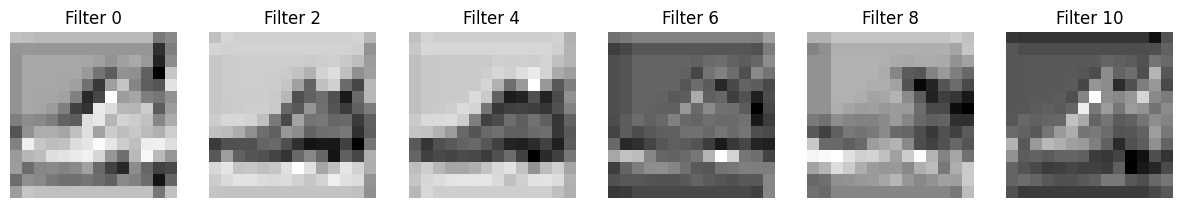

In [5]:
# Plot first 6 feature maps from conv1
act = feature_maps['conv2'].squeeze()  # shape [32,28,28]
fig, axes = plt.subplots(1, 6, figsize=(15, 5))
for i in range(6):
    axes[i].imshow(act[2*i].cpu(), cmap='gray')
    axes[i].set_title(f'Filter {2*i}')
    axes[i].axis('off')
plt.show()

In [8]:
direction_list = [[1, 0],  [0, 1],  [-1, 0],  [0, -1]]
center_list = [
    [6, 2],
    [2, 6],
    [10, 6],
    [6, 10],
]

# Creating a list of all filtration transformer, we will be applying
filtration_list = ( [HeightFiltration(direction=np.array(direction), n_jobs=-1) for direction in direction_list]
    + [RadialFiltration(center=np.array(center), n_jobs=-1) for center in center_list] )

diagram_steps = [
    [   Binarizer(threshold=0.05, n_jobs=-1),
        filtration,
        CubicalPersistence(n_jobs=-1),
        Scaler(n_jobs=-1),
    ]
    for filtration in filtration_list
]
# Add one extra pipeline WITHOUT binarizer & filtration
step = [
    Normalize255(),
    CubicalPersistence(n_jobs=-1),
    Scaler(n_jobs=-1),
]

diagram_steps += [step] * 3


metric_list_small = [
    {"metric": "betti", "metric_params": {"p": 1, "n_bins": 50}},
]
feature_union_small = make_union(
    PersistenceEntropy(nan_fill_value=-1),
    *[Amplitude(**metric, n_jobs=-1,) for metric in metric_list_small]
)
tda_pipeline = make_union(
    *[make_pipeline(*diagram_step, feature_union_small) for diagram_step in diagram_steps],
    n_jobs=-1
)

class SafeTDA(BaseEstimator, TransformerMixin):
    def __init__(self, pipeline, output_dim):
        self.pipeline = pipeline
        self.output_dim = output_dim

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        try:
            return self.pipeline.fit_transform(X)
        except ValueError:
            print(f'zero vector added')
            return np.zeros((X.shape[0], self.output_dim))
        
tda_pipeline_safe = SafeTDA(tda_pipeline, output_dim=32)

In [9]:
conv2_maps = feature_maps['conv2'].squeeze().cpu().numpy()
fmap = conv2_maps[0]
binarizer = Binarizer(threshold=0.05)
fmap_binarized = binarizer.fit_transform(fmap[np.newaxis, :, :])

binarizer.plot(fmap_binarized)

In [10]:
radial_filtration = RadialFiltration(center=np.array([10, 5]))
fmap_filtration = radial_filtration.fit_transform(fmap_binarized)

radial_filtration.plot(fmap_filtration, colorscale="jet")

In [11]:
cubical_persistence = CubicalPersistence(n_jobs=-1)
fmap_cubical = cubical_persistence.fit_transform(fmap_filtration)

cubical_persistence.plot(fmap_cubical)

In [12]:
import torch
import numpy as np
from joblib import Parallel, delayed

# --- GPU/CPU setup (same as before) ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
model.to(device)

# --- Helper function to process one feature map ---
# We define this so joblib can call it in parallel.
def process_fmap(fmap):
    """Runs the TDA pipeline on a single feature map."""
    fmap = fmap.astype(np.float32)
    try:
        # Input shape for the pipeline is (n_samples, height, width)
        return tda_pipeline_safe.fit_transform(fmap[np.newaxis, :, :])
    except Exception as e:
        print(f"Skipping one fmap due to error: {e}")
        # Return a zero vector with the correct output dimension
        return np.zeros((1, 32))

# --- Main Loop ---
vectors = []
model.eval()

for i in range(100):
    image, label = test_dataset[i]
    image = image.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(image)

    print(f"Image {i+1}/100 - Predicted: {output.argmax(dim=1).item()}, Actual: {label}")

    conv2_maps = feature_maps['conv2'].squeeze().cpu().numpy() # Shape: (64, 14, 14)

    # --- This is the key optimization ---
    # Use joblib to run process_fmap on all 64 maps in parallel.
    # n_jobs=-1 tells it to use all available CPU cores.
    tda_features_list = Parallel(n_jobs=-1)(delayed(process_fmap)(fmap) for fmap in conv2_maps)

    # Stack the list of (1, 32) arrays into a single (1, 2048) array
    tda_features = np.hstack(tda_features_list)
    vectors.append(tda_features)

print("\nProcessing complete!")

Using device: cpu
Image 1/100 - Predicted: 9, Actual: 9
Image 2/100 - Predicted: 2, Actual: 2
Image 3/100 - Predicted: 1, Actual: 1
Image 4/100 - Predicted: 1, Actual: 1
Image 5/100 - Predicted: 6, Actual: 6
Image 6/100 - Predicted: 1, Actual: 1
Image 7/100 - Predicted: 4, Actual: 4
Image 8/100 - Predicted: 6, Actual: 6
Image 9/100 - Predicted: 5, Actual: 5
Image 10/100 - Predicted: 7, Actual: 7
Image 11/100 - Predicted: 4, Actual: 4
Image 12/100 - Predicted: 5, Actual: 5
Image 13/100 - Predicted: 7, Actual: 7
Image 14/100 - Predicted: 3, Actual: 3
Image 15/100 - Predicted: 4, Actual: 4
Image 16/100 - Predicted: 1, Actual: 1
Image 17/100 - Predicted: 2, Actual: 2
Image 18/100 - Predicted: 6, Actual: 4
Image 19/100 - Predicted: 8, Actual: 8
Image 20/100 - Predicted: 0, Actual: 0
Image 21/100 - Predicted: 2, Actual: 2
Image 22/100 - Predicted: 7, Actual: 5
Image 23/100 - Predicted: 7, Actual: 7
Image 24/100 - Predicted: 5, Actual: 9
Image 25/100 - Predicted: 1, Actual: 1
Image 26/100 - P

In [13]:
true_labels = []
for i in range(100):
    image, label = test_dataset[i]
    true_labels.append(label)

In [16]:
#X, y_true = np.array(vectors), np.array(true_labels)
X = np.vstack(vectors)
y_true = np.array(true_labels)
X = np.squeeze(X)
df = pd.DataFrame(X)
df['true_label'] = y_true

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 2516 and the array at index 1 has size 2588

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_true, test_size=0.2, random_state=42)

# Initialize and train the Random Forest model
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)

# Make predictions and evaluate accuracy
y_pred = rf_classifier.predict(X_test)
rf_accuracy = accuracy_score(y_test, y_pred)
print(f"Random Forest Accuracy: {rf_accuracy:.2f}")

Random Forest Accuracy: 0.25


Answer: Maybe Not